# 📚 מחברת 1: ויקיפדיה כמקור נתונים ורשתות ידע
## מבוא למדעי הרוח הדיגיטליים | אוניברסיטת אריאל | תשפ"ו
### פרופ' שי גורדין
---
**מה נלמד במחברת זו?**

במחברת זו נלמד כיצד ויקיפדיה משמשת כמקור נתונים עבור מחקר מדעי הרוח, ולבנות רשת ידע אינטראקטיבית.

**נושאים:**
1. ויקיפדיה כמקור מידע – יתרונות ומגבלות
2. ה-API של מדיה-ויקי – גישה תכנותית
3. שליפת נתונים מקטגוריות עבריות
4. בניית רשת ידע עם NetworkX
5. ויזואליזציה אינטראקטיבית עם PyVis
6. ניתוח פערים – ערכים חסרים = פרויקטי סיום!

**🎯 הקטגוריות שנחקור:**
- 🏺 ארכיאולוגיה של ארץ ישראל
- 📜 היסטוריה של עם ישראל
- 💻 מדעי הרוח הדיגיטליים

---
## 🗺️ מדריך שימוש במחברת

| | |
|---|---|
| ⏱️ **זמן מוערך** | 🏫 בכיתה: ~50 דקות | 🏠 בבית: ~40 דקות נוספות |
| 💻 **היכן להריץ** | Google Colab בלבד (כפתור ▶ למעלה) |
| 🌐 **חיבור רשת** | נדרש לחלק ב׳ ומעלה (שליפת ויקיפדיה) |

### סדר ריצה:
> **חשוב:** הריצו תאים **מלמעלה למטה**, בסדר. אל תדלגו!

```
תא 1 → התקנת ספריות  (חכו עד שמופיע ✅)
תא 2 → יבוא ספריות   (חכו עד שמופיע ✅)
תא 3 → הגדרת המחלקה  (חכו עד שמופיע ✅ ונמצאו X ערכים)
...וכן הלאה
```

### 🆘 קיבלתם שגיאה?
1. **קראו** את הודעת השגיאה — בדרך כלל מסבירה מה קרה
2. **הריצו מחדש** את התא (לחצו ▶ שוב)
3. **שאלו את Gemini**: העתיקו את הודעת השגיאה לשורת החיפוש של [Gemini](https://gemini.google.com) ורשמו "מה אומרת שגיאה זו בפייתון ואיך לפתור?"
4. **שאלו את המרצה** אם הבעיה נמשכת

---


## חלק א: ויקיפדיה כמקור נתונים מחקרי

### מדוע ויקיפדיה מעניינת את מדעי הרוח הדיגיטליים?

ויקיפדיה אינה רק אנציקלופדיה – היא **מסד נתונים ענק** של ידע אנושי מובנה:

| מאפיין | פרטים |
|--------|--------|
| **היקף** | ~6.7M ערכים באנגלית, ~380K בעברית |
| **קישוריות** | כל ערך מקושר לאחרים = רשת ידע |
| **קטגוריות** | ארגון היררכי של ידע |
| **היסטוריית עריכות** | ניתן לחקור התפתחות ידע לאורך זמן |
| **API חינמי** | גישה פרוגרמטית מלאה |

### שאלות מחקריות:
- אילו נושאים **מיוצגים-חסר** (underrepresented)?
- כיצד **מתפתח הידע** לאורך זמן?
- מהי **הרשת** של קשרים בין מושגים?
- מה ה**"ליבה"** של שדה ידע?

> 📖 לקריאה: Niederer & van Dijck (2010). *Wisdom of the crowd or technicity of content?* New Media & Society.

In [1]:
# התקנת ספריות נדרשות
# % pip  = מתקין לתוך הסביבה הנוכחית (עובד גם ב-Colab וגם ב-Jupyter מקומי)
%pip install pyvis wikipedia-api tqdm python-bidi scipy -q

print("✅ הספריות הותקנו!")
print("   • pyvis        - ויזואליזציה אינטראקטיבית")
print("   • wikipedia-api - גישה ל-API")
print("   • tqdm         - סרגל התקדמות")
print("   • python-bidi  - תצוגת עברית תקינה בגרפים")
print("   • scipy        - חישובי PageRank ומידות מרכזיות")



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.10/bin/python3.10 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
✅ הספריות הותקנו!
   • pyvis        - ויזואליזציה אינטראקטיבית
   • wikipedia-api - גישה ל-API
   • tqdm         - סרגל התקדמות
   • python-bidi  - תצוגת עברית תקינה בגרפים
   • scipy        - חישובי PageRank ומידות מרכזיות


In [2]:
# יבוא ספריות
import requests          # שליפת נתונים מהרשת
import json              # עיבוד JSON
import pandas as pd      # ניהול נתונים בטבלאות
import networkx as nx    # בניית ועיבוד גרפים
from pyvis.network import Network   # ויזואליזציה אינטראקטיבית
import time              # עיכובים בין בקשות
from tqdm.auto import tqdm          # סרגל התקדמות (גם ללא ipywidgets)
from IPython.display import HTML, display
import matplotlib.pyplot as plt
import matplotlib
import os
from bidi.algorithm import get_display  # תיקון כיוון טקסט עברי בגרפים

matplotlib.rcParams['axes.unicode_minus'] = False

print("✅ כל הספריות יובאו!")
print(f"   NetworkX {nx.__version__} | Pandas {pd.__version__}")

✅ כל הספריות יובאו!
   NetworkX 3.4.2 | Pandas 2.3.3


/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## חלק ב: ה-API של ויקיפדיה

### מהו API?
**API** (Application Programming Interface) = ממשק תכנות יישומים.  
חשבו עליו כ"תפריט" – אנחנו בוחרים מה לבקש, ה-API מחזיר את הנתונים.

### כתובת הבסיס של ויקיפדיה העברית:
```
https://he.wikipedia.org/w/api.php
```

### דוגמה לבקשה:
```
https://he.wikipedia.org/w/api.php?action=query&list=categorymembers&cmtitle=קטגוריה:ארכיאולוגיה_של_ארץ_ישראל&format=json
```

### פרמטרים עיקריים:
| פרמטר | תיאור |
|--------|-------|
| `action=query` | שאילתת מידע |
| `list=categorymembers` | רשימת חברי קטגוריה |
| `prop=links` | קישורים בתוך ערך |
| `prop=extracts` | תוכן/תקציר הערך |
| `format=json` | פורמט התגובה |

📖 **תיעוד מלא**: https://www.mediawiki.org/wiki/API:Main_page

---

## 🌐 כלים מקוונים ללא קוד – לסיור ראשון בויקיפדיה

לפני שנכתוב קוד, כדאי לדעת שאפשר לבצע **חלק מהשאילתות שנלמד היום ישירות בדפדפן** — ללא שורת Python אחת.

### 🔗 כלים מומלצים

| כלי | מה אפשר לעשות | קישור |
|-----|--------------|-------|
| **Six Degrees of Wikipedia** | מוצא את הנתיב הקצר ביותר בין שני ערכים — ויזואלי ומרשים! | [sixdegreesofwikipedia.com](https://www.sixdegreesofwikipedia.com/?source=%D7%9E%D7%92%D7%99%D7%93%D7%95&target=%D7%92%D7%9C%D7%95%D7%AA+%D7%91%D7%91%D7%9C) |
| **PetScan** | שאילתות מתקדמות על קטגוריות ויקיפדיה בממשק גרפי | [petscan.wmcloud.org](https://petscan.wmcloud.org/) |
| **API Sandbox (ויקיפדיה)** | ניסוי בקשות API ישירות ב-Wikipedia ללא קוד | [מיוחד:ApiSandbox](https://he.wikipedia.org/wiki/%D7%9E%D7%99%D7%95%D7%97%D7%93:ApiSandbox) |
| **דף הקטגוריה עצמו** | ריצה ידנית — רשימת כל הערכים בקטגוריה | [ארכאולוגיה של ארץ ישראל](https://he.wikipedia.org/wiki/%D7%A7%D7%98%D7%92%D7%95%D7%A8%D7%99%D7%94:%D7%90%D7%A8%D7%9B%D7%90%D7%95%D7%9C%D7%95%D7%92%D7%99%D7%94_%D7%A9%D7%9C_%D7%90%D7%A8%D7%A5_%D7%99%D7%A9%D7%A8%D7%90%D7%9C) |

### 🎓 דוגמה להדגמה בכיתה — Six Degrees

פתחו את הקישור: **[מגידו ← גלות בבל](https://www.sixdegreesofwikipedia.com/?source=%D7%9E%D7%92%D7%99%D7%93%D7%95&target=%D7%92%D7%9C%D7%95%D7%AA+%D7%91%D7%91%D7%9C)**

תוכלו לראות בדיוק אחד ה*edges* שהגרף שלנו יבנה — בצורה ויזואלית ואינטואיטיבית.

> **שאלה לדיון**: כמה "צעדים" לוקח להגיע מ-**מגידו** ל-**גלות בבל**?  
> נסו גם: מגידו ← ניתוח רשתות חברתיות. מה מגלה המסלול על המבנה של ידע בויקיפדיה?

---


In [3]:
# ============================================================
# מחלקת גישה לוויקיפדיה העברית
# ============================================================

class HebrewWikipedia:
    """
    ממשק לוויקיפדיה העברית דרך MediaWiki API.
    
    שימוש:
        wiki = HebrewWikipedia()
        pages = wiki.get_category_members("ארכיאולוגיה של ארץ ישראל")
        links = wiki.get_page_links("מגידו")
    """
    
    BASE_URL = "https://he.wikipedia.org/w/api.php"
    
    def __init__(self, delay=0.15):
        """
        אתחול הממשק.
        delay: עיכוב (שניות) בין בקשות – כיבוד מגבלות השרת
        """
        self.session = requests.Session()
        self.delay = delay
        # חשוב: זיהוי הבוט – כיבוד נוהלי ויקיפדיה
        self.session.headers.update({
            'User-Agent': 'IntroDH-Course-Bot/1.0 (Ariel University; Educational) '
                          'Contact: shygordin@gmail.com'
        })
    
    def _request(self, params):
        """שליחת בקשה ל-API עם טיפול בשגיאות. פונקציה פנימית."""
        params['format'] = 'json'
        # ויקיפדיה מצפה לקווים תחתונים (לא רווחים) בשמות הדפים בפרמטרי ה-API
        for key in ('cmtitle', 'titles', 'page'):
            if key in params:
                params[key] = params[key].replace(' ', '_')
        try:
            resp = self.session.get(self.BASE_URL, params=params, timeout=30)
            resp.raise_for_status()
            time.sleep(self.delay)
            return resp.json()
        except Exception as e:
            print(f"⚠️ שגיאה: {e}")
            return {}
    
    def get_category_members(self, category_name, depth=1, max_pages=None):
        """
        שליפת כל הערכים בקטגוריה (כולל תת-קטגוריות).
        
        פרמטרים:
            category_name : שם הקטגוריה ללא הקידומת "קטגוריה:"
            depth         : עומק חיפוש בתת-קטגוריות (ברירת מחדל: 1)
                            שימו לב: קטגוריות גדולות כמו ארכיאולוגיה דורשות depth=2!
            max_pages     : מגבלת ערכים (None = ללא מגבלה)
        
        מחזיר: רשימת dict עם: title, pageid, category
        """
        pages = []
        seen_cats = set()
        
        def _fetch(cat, current_depth):
            if cat in seen_cats or current_depth > depth:
                return
            if max_pages and len(pages) >= max_pages:
                return
            seen_cats.add(cat)
            
            continue_key = None
            while True:
                params = {
                    'action': 'query',
                    'list': 'categorymembers',
                    'cmtitle': f'קטגוריה:{cat}',
                    'cmlimit': 500,
                    'cmtype': 'page|subcat'
                }
                if continue_key:
                    params['cmcontinue'] = continue_key
                
                data = self._request(params)
                if 'query' not in data:
                    break
                
                for item in data['query']['categorymembers']:
                    if item['ns'] == 0:  # ערך רגיל
                        if not any(p['title'] == item['title'] for p in pages):
                            pages.append({
                                'title': item['title'],
                                'pageid': item['pageid'],
                                'category': category_name
                            })
                    elif item['ns'] == 14 and current_depth < depth:  # תת-קטגוריה
                        subcat = item['title'].replace('קטגוריה:', '')
                        _fetch(subcat, current_depth + 1)
                
                if 'continue' in data:
                    continue_key = data['continue']['cmcontinue']
                else:
                    break
        
        _fetch(category_name, 0)
        return pages
    
    def get_page_links(self, title, filter_titles=None):
        """
        שליפת קישורים פנימיים מתוך ערך.
        
        פרמטרים:
            title         : כותרת הערך
            filter_titles : אם סופק, מחזיר רק קישורים לכותרות אלו
        
        מחזיר: רשימת כותרות מקושרות
        """
        links = []
        continue_key = None
        
        while True:
            params = {
                'action': 'query',
                'prop': 'links',
                'titles': title,
                'pllimit': 500,
                'plnamespace': 0
            }
            if continue_key:
                params['plcontinue'] = continue_key
            
            data = self._request(params)
            if 'query' not in data:
                break
            
            for pid, pdata in data['query']['pages'].items():
                for link in pdata.get('links', []):
                    t = link['title']
                    if filter_titles is None or t in filter_titles:
                        links.append(t)
            
            if 'continue' in data:
                continue_key = data['continue']['plcontinue']
            else:
                break
        
        return links
    
    def get_page_summary(self, title):
        """שליפת תקציר ומידע בסיסי על ערך."""
        data = self._request({
            'action': 'query',
            'prop': 'extracts|info',
            'titles': title,
            'exintro': True,
            'exchars': 800,
            'inprop': 'url'
        })
        if 'query' not in data:
            return {}
        for pid, pdata in data['query']['pages'].items():
            if pid != '-1':
                return pdata
        return {}
    
    def check_exists(self, titles):
        """
        בדיקת קיום רשימת ערכים.
        מחזיר dict: {כותרת: True/False}
        עובד באצוות של 50.
        """
        results = {}
        for i in range(0, len(titles), 50):
            batch = titles[i:i+50]
            data = self._request({
                'action': 'query',
                'prop': 'info',
                'titles': '|'.join(batch)
            })
            if 'query' not in data:
                continue
            for pid, pdata in data['query']['pages'].items():
                exists = pid != '-1' and 'missing' not in pdata
                results[pdata['title']] = exists
        return results
    
    def get_red_links(self, title):
        """
        שליפת קישורים אדומים (ערכים מוזכרים אך לא קיימים).
        אלו הם פערי הידע בוויקיפדיה!
        """
        data = self._request({
            'action': 'parse',
            'page': title,
            'prop': 'links'
        })
        missing = []
        if 'parse' in data:
            for link in data['parse'].get('links', []):
                if link.get('ns') == 0 and 'exists' not in link:
                    m = link.get('*', '')
                    if m:
                        missing.append(m)
        return missing


# ── יצירת אובייקט ויקיפדיה ──
wiki = HebrewWikipedia(delay=0.15)
print("✅ ממשק ויקיפדיה מוכן!")
print()
print("🔍 בודק חיבור לוויקיפדיה...")
print("   (שולף כמה ערכים לבדיקה – עשוי לקחת 10–20 שניות)")
try:
    test = wiki.get_category_members("ארכאולוגיה של ארץ ישראל", depth=1, max_pages=10)
    print(f"   ✅ החיבור תקין! נמצאו {len(test)} ערכים (מבדיקת מדגם)")
    if test:
        print(f"   דוגמה: {test[0]['title']}, {test[1]['title'] if len(test)>1 else ''}")
    if len(test) == 0:
        print("   ⚠️ 0 ערכים — ייתכן שהאינטרנט חסום. נסו DEMO_MODE=True בתא הבא.")
except Exception as exc:
    print(f"   ⚠️ בעיית רשת: {exc}")
    print("   → בדקו את חיבור האינטרנט ונסו שוב")
    print("   → אם הבעיה נמשכת, השתמשו ב-DEMO_MODE בתא הבא")


✅ ממשק ויקיפדיה מוכן!

🔍 בודק חיבור לוויקיפדיה...
   (שולף כמה ערכים לבדיקה – עשוי לקחת 10–20 שניות)
   ✅ החיבור תקין! נמצאו 57 ערכים (מבדיקת מדגם)
   דוגמה: ארכאולוגיה של ארץ ישראל, Mission de Phénicie


In [4]:
# ============================================================
# הגדרת הקטגוריות ונתוני הויזואליזציה
# ============================================================

CATEGORIES = {
    'ארכאולוגיה של ארץ ישראל': {
        'color': '#e74c3c',
        'bg_color': '#fadbd8',
        'icon': '🏺',
        'group': 1,
        'depth': 1,       # קטגוריה שטוחה – מאמרים ישירים ברמה 1
        'max_pages': 100
    },
    'תולדות עם ישראל': {
        'color': '#2980b9',
        'bg_color': '#d6eaf8',
        'icon': '📜',
        'group': 2,
        'depth': 1,       # קטגוריה קיימת ועם ~50 ערכים ברמה ראשונה
        'max_pages': 100
    },
    'מדעי הרוח הדיגיטליים': {
        'color': '#27ae60',
        'bg_color': '#d5f5e3',
        'icon': '💻',
        'group': 3,
        'depth': 1,       # קטגוריה שטוחה – מאמרים ישירים
        'max_pages': 80
    }
}

print("📋 קטגוריות מוגדרות:")
for cat, info in CATEGORIES.items():
    print(f"  {info['icon']}  {cat}  (עומק={info['depth']})")


📋 קטגוריות מוגדרות:
  🏺  ארכאולוגיה של ארץ ישראל  (עומק=1)
  📜  תולדות עם ישראל  (עומק=1)
  💻  מדעי הרוח הדיגיטליים  (עומק=1)


---
## 🏫 חלק ב׳ — שליפת נתונים (בכיתה יחד)

> ⏱️ **הערה לסבלנות**: השליפה הבאה שולחת מאות בקשות לשרת ויקיפדיה ועשויה לקחת **5–10 דקות**.  
> זה נורמלי! ראו את הסרגל מתקדם ואל תסגרו את הדפדפן.
>
> 💡 אם אתם לא בחיבור אינטרנט טוב, **הדליקו את DEMO_MODE=True** בתא הבא — זה ייתן לכם נתוני דוגמה להמשך.


In [5]:
# ============================================================
# הגדרת מצב עבודה
# ============================================================
# שנו ל-True אם:
#   - אין חיבור אינטרנט תקין
#   - השליפה לוקחת יותר מדי זמן
#   - רוצים לתרגל ניתוח על נתונים מוכנים

DEMO_MODE = False   # ← שנו ל-True כדי לדלג על שליפת ויקיפדיה

# נתוני דוגמה (ישמשו כאשר DEMO_MODE=True)
DEMO_PAGES = [
    {'title': 'מגידו', 'pageid': 51200, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'תל חצור', 'pageid': 57301, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'תל לכיש', 'pageid': 42100, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'בית שאן', 'pageid': 38200, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'תל באר שבע', 'pageid': 33100, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'יריחו', 'pageid': 29400, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'אשדוד', 'pageid': 26300, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'תקופת הברזל', 'pageid': 22100, 'category': 'ארכאולוגיה של ארץ ישראל'},
    {'title': 'גלות בבל', 'pageid': 71200, 'category': 'תולדות עם ישראל'},
    {'title': 'ממלכת ישראל', 'pageid': 65400, 'category': 'תולדות עם ישראל'},
    {'title': 'ממלכת יהודה', 'pageid': 62300, 'category': 'תולדות עם ישראל'},
    {'title': 'שיבת ציון', 'pageid': 58900, 'category': 'תולדות עם ישראל'},
    {'title': 'המרד הגדול', 'pageid': 54100, 'category': 'תולדות עם ישראל'},
    {'title': 'ספרות עברית', 'pageid': 49200, 'category': 'תולדות עם ישראל'},
    {'title': 'דיגיטציה', 'pageid': 31000, 'category': 'מדעי הרוח הדיגיטליים'},
    {'title': 'קריאה מרחוק', 'pageid': 28500, 'category': 'מדעי הרוח הדיגיטליים'},
    {'title': 'ניתוח רשתות חברתיות', 'pageid': 25100, 'category': 'מדעי הרוח הדיגיטליים'},
]

# נתוני קשרים לדוגמה (אמולציה של קישורים בין ערכים)
DEMO_EDGES = [
    ('מגידו', 'תקופת הברזל'), ('תל חצור', 'תקופת הברזל'), ('תל לכיש', 'ממלכת יהודה'),
    ('ממלכת ישראל', 'ממלכת יהודה'), ('גלות בבל', 'ממלכת יהודה'), ('שיבת ציון', 'גלות בבל'),
    ('המרד הגדול', 'ממלכת יהודה'), ('דיגיטציה', 'קריאה מרחוק'), ('קריאה מרחוק', 'ספרות עברית'),
    ('ניתוח רשתות חברתיות', 'קריאה מרחוק'), ('בית שאן', 'מגידו'), ('תל באר שבע', 'ממלכת יהודה'),
]

if DEMO_MODE:
    print("🟡 מצב דמו פעיל — משתמשים בנתוני דוגמה")
else:
    print("🟢 מצב חי — נשלוף נתונים אמיתיים מוויקיפדיה")


🟢 מצב חי — נשלוף נתונים אמיתיים מוויקיפדיה


In [6]:
# ============================================================
# שליפת כל הערכים מוויקיפדיה (או טעינת נתוני דמו)
# ============================================================
# ⏱️ במצב חי: תהליך זה עשוי לקחת 5–10 דקות.
#   ראו את הסרגלים מתקדמים — אל תפסיקו את הריצה!

import time as _time
_start = _time.time()

if DEMO_MODE:
    # ───── מצב דמו ─────
    all_pages = DEMO_PAGES.copy()
    df = pd.DataFrame(all_pages)
    print("🟡 נטענו נתוני דמו:")
    for cat in df['category'].unique():
        n = len(df[df['category']==cat])
        print(f"   {CATEGORIES[cat]['icon']} {cat}: {n} ערכים")
    print(f"\n📊 סה\"כ: {len(df)} ערכים (דמו)")
    display(df.head(8))

else:
    # ───── מצב חי ─────
    print("📥 שולף ערכים מוויקיפדיה העברית...")
    print("=" * 55)
    print("⏳ השליפה עשויה לקחת 5–10 דקות — המתינו בסבלנות!")
    print()

    all_pages = []
    category_pages = {}

    for cat_name, cat_info in CATEGORIES.items():
        cat_depth = cat_info.get('depth', 1)
        cat_max   = cat_info.get('max_pages', None)
        print(f"\n{cat_info['icon']} שולף: {cat_name}")
        print(f"   (עומק={cat_depth}, מקסימום={cat_max or 'ללא הגבלה'} ערכים)")
        
        pages = wiki.get_category_members(cat_name, depth=cat_depth, max_pages=cat_max)
        category_pages[cat_name] = pages
        all_pages.extend(pages)
        
        print(f"   ✓ נמצאו {len(pages)} ערכים")

    print("\n" + "=" * 55)
    print(f"📊 סה\"כ: {len(all_pages)} ערכים")

    # יצירת DataFrame
    df = pd.DataFrame(all_pages).drop_duplicates('title').reset_index(drop=True)
    print(f"   לאחר הסרת כפילויות: {len(df)} ערכים ייחודיים")
    print()
    display(df.head(8))

elapsed = _time.time() - _start
print(f"\n⏱️ זמן שחלף: {elapsed:.0f} שניות")

print("✅ נתוני הבסיס מוכנים — ממשיכים לניתוח!")

📥 שולף ערכים מוויקיפדיה העברית...
⏳ השליפה עשויה לקחת 5–10 דקות — המתינו בסבלנות!


🏺 שולף: ארכאולוגיה של ארץ ישראל
   (עומק=1, מקסימום=100 ערכים)
   ✓ נמצאו 104 ערכים

📜 שולף: תולדות עם ישראל
   (עומק=1, מקסימום=100 ערכים)
   ✓ נמצאו 145 ערכים

💻 שולף: מדעי הרוח הדיגיטליים
   (עומק=1, מקסימום=80 ערכים)
   ✓ נמצאו 59 ערכים

📊 סה"כ: 308 ערכים
   לאחר הסרת כפילויות: 308 ערכים ייחודיים



,title,pageid,category
0,ארכאולוגיה של ארץ ישראל,368147,ארכאולוגיה של ארץ ישראל
1,Mission de Phénicie,2153878,ארכאולוגיה של ארץ ישראל
2,אבן מגדלא,2176801,ארכאולוגיה של ארץ ישראל
3,אמות המים של קיסריה,774961,ארכאולוגיה של ארץ ישראל
4,ארכאולוגיה מקראית,18139,ארכאולוגיה של ארץ ישראל
5,ארכאומטלורגיה אל-ברזלית בדרום הלבנט,964619,ארכאולוגיה של ארץ ישראל
6,אתרי המקרא,475661,ארכאולוגיה של ארץ ישראל
7,בבתא,677100,ארכאולוגיה של ארץ ישראל



⏱️ זמן שחלף: 3 שניות
✅ נתוני הבסיס מוכנים — ממשיכים לניתוח!


📊 התפלגות לפי קטגוריה:
  📜 תולדות עם ישראל                      145 |█████████████████████████████
  🏺 ארכאולוגיה של ארץ ישראל              104 |████████████████████
  💻 מדעי הרוח הדיגיטליים                  59 |███████████


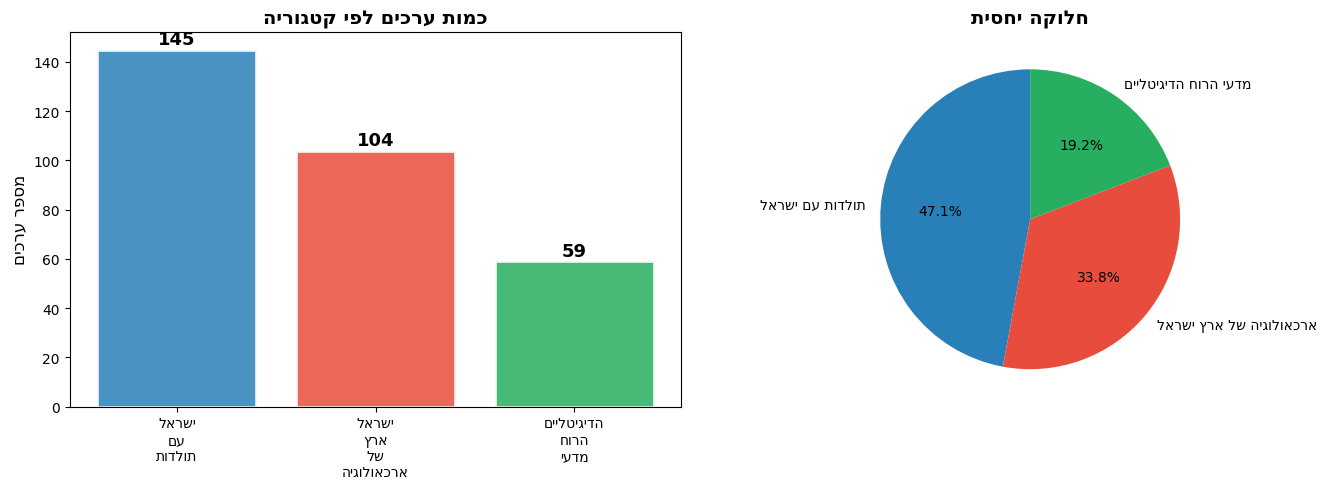

💾 הגרף נשמר: 01_category_distribution.png


In [7]:
# ============================================================
# ניתוח ראשוני: גרף התפלגות
# ============================================================

counts = df.groupby('category').size().sort_values(ascending=False)

print("📊 התפלגות לפי קטגוריה:")
for cat, n in counts.items():
    icon = CATEGORIES[cat]['icon']
    bar_str = '█' * (n // 5)
    print(f"  {icon} {cat[:35]:<35} {n:>4} |{bar_str}")

# גרף
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
colors = [CATEGORIES[c]['color'] for c in counts.index]

# תיקון כיוון עברית ב-matplotlib באמצעות python-bidi
def rtl(text):
    """מכין מחרוזת עברית לתצוגה תקינה בגרפי matplotlib."""
    return get_display(text)

# עמודות
bars = ax1.bar(range(len(counts)), counts.values,
               color=colors, alpha=0.85, edgecolor='white', linewidth=2)
ax1.set_xticks(range(len(counts)))
ax1.set_xticklabels([rtl(c).replace(' ', '\n') for c in counts.index], fontsize=10)
ax1.set_ylabel(rtl('מספר ערכים'), fontsize=12)
ax1.set_title(rtl('כמות ערכים לפי קטגוריה'), fontsize=14, fontweight='bold')
for bar, val in zip(bars, counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
             str(val), ha='center', va='bottom', fontsize=13, fontweight='bold')

# עוגה
ax2.pie(counts.values, labels=[rtl(c) for c in counts.index], colors=colors,
        autopct='%1.1f%%', startangle=90,
        textprops={'fontsize': 10})
ax2.set_title(rtl('חלוקה יחסית'), fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_category_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 הגרף נשמר: 01_category_distribution.png")


## חלק ג: תיאוריית רשתות – Network Analysis

### מה זה גרף / רשת?
**גרף** הוא מבנה מתמטי המורכב מ:
- **צמתים** (Nodes): הישויות – כאן, ערכי ויקיפדיה
- **קשתות** (Edges): הקשרים – קישורים בין ערכים

### מדדי מרכזיות:

| מדד | הסבר | שימוש |
|-----|-------|-------|
| **In-Degree** | כמה ערכים מקשרים לכאן | "כמה פופולרי" |
| **Out-Degree** | כמה ערכים הערך מקשר אליהם | "כמה מחובר" |
| **PageRank** | אלגוריתם גוגל – חשיבות יחסית | "כמה סמכותי" |
| **Betweenness** | כמה פעמים על נתיב קצר | "גשר בין קבוצות" |

### גרף מכוון לעומת לא מכוון:
- **מכוון (Directed)**: קישור מ-א ל-ב ≠ קישור מ-ב ל-א
- **לא מכוון**: כל קישור הוא דו-כיווני

ויקיפדיה = **גרף מכוון** (ערך א' מקשר לב', אבל לא בהכרח ב' מקשר לא').

📖 **מומלץ**: Barabási, A.L. (2016). *Network Science*. (חינם: networksciencebook.com)

In [8]:
# ============================================================
# בניית רשת הידע
# ============================================================
# 🏫 בכיתה: הריצו תא זה ועקבו אחר הסרגלים
# ⏱️ במצב חי: עד 10 דקות. במצב דמו: מהיר מאוד.

print("🕸️  בונה רשת ידע...")
print("=" * 55)

G = nx.DiGraph()

all_titles = set(df['title'].tolist())

# ── שלב 1: הוספת צמתים ──
print("📌 מוסיף צמתים...")
for _, row in df.iterrows():
    cat = row['category']
    G.add_node(
        row['title'],
        category=cat,
        color=CATEGORIES[cat]['color'],
        group=CATEGORIES[cat]['group'],
        pageid=str(row['pageid'])
    )
print(f"   {G.number_of_nodes()} צמתים נוספו")

# ── שלב 2: שליפת/הגדרת קשתות ──
if DEMO_MODE:
    print(f"\n🔗 מוסיף קשתות מנתוני דמו...")
    for src, tgt in DEMO_EDGES:
        if src in all_titles and tgt in all_titles:
            G.add_edge(src, tgt)
    print(f"   {G.number_of_edges()} קשתות נוספו")
else:
    print(f"\n🔗 שולף קישורים עבור {len(all_titles)} ערכים...")
    print("   (שולף רק קישורים בין ערכים ברשימה שלנו)")
    print("   ⏳ עשוי לקחת כמה דקות נוספות...")
    with tqdm(total=len(all_titles), desc="שליפת קישורים") as pbar:
        for title in list(all_titles):
            links = wiki.get_page_links(title, filter_titles=all_titles)
            for link in links:
                if link != title:
                    G.add_edge(title, link)
            pbar.update(1)

print(f"\n✅ הרשת נבנתה!")
print(f"   צמתים : {G.number_of_nodes():,}")
print(f"   קשתות : {G.number_of_edges():,}")
print(f"   צפיפות: {nx.density(G):.4f}")
print()
print("💡 מה אומרת הצפיפות?")
print(f"   צפיפות {nx.density(G):.4f} = {nx.density(G)*100:.1f}% מהקשרים האפשריים קיימים")
print("   רשת ריאלית תמיד דלילה — ערכים לא מקושרים לכולם!")


🕸️  בונה רשת ידע...
📌 מוסיף צמתים...
   308 צמתים נוספו

🔗 שולף קישורים עבור 308 ערכים...
   (שולף רק קישורים בין ערכים ברשימה שלנו)
   ⏳ עשוי לקחת כמה דקות נוספות...


שליפת קישורים: 100%|██████████| 308/308 [02:02<00:00,  2.52it/s]


✅ הרשת נבנתה!
   צמתים : 308
   קשתות : 1,712
   צפיפות: 0.0181

💡 מה אומרת הצפיפות?
   צפיפות 0.0181 = 1.8% מהקשרים האפשריים קיימים
   רשת ריאלית תמיד דלילה — ערכים לא מקושרים לכולם!


In [9]:
# ============================================================
# ניתוח סטטיסטי – מדדי מרכזיות
# ============================================================

print("📊 מחשב מדדי מרכזיות...")

in_deg  = dict(G.in_degree())
out_deg = dict(G.out_degree())
pagerank = nx.pagerank(G, alpha=0.85)

# הוספה כתכונות צמתים
for n in G.nodes():
    G.nodes[n]['in_degree']  = in_deg.get(n, 0)
    G.nodes[n]['out_degree'] = out_deg.get(n, 0)
    G.nodes[n]['degree']     = in_deg.get(n, 0) + out_deg.get(n, 0)
    G.nodes[n]['pagerank']   = round(pagerank.get(n, 0), 6)

# טבלת נתונים
stats = []
for n in G.nodes():
    nd = G.nodes[n]
    stats.append({
        'כותרת':            n,
        'קטגוריה':          nd.get('category', ''),
        'קישורים_נכנסים':   nd['in_degree'],
        'קישורים_יוצאים':   nd['out_degree'],
        'סך_קישורים':       nd['degree'],
        'PageRank':         nd['pagerank']
    })

df_stats = pd.DataFrame(stats).sort_values('PageRank', ascending=False).reset_index(drop=True)
df_stats.to_csv('02_network_stats.csv', index=False, encoding='utf-8-sig')

print("\n⭐ 15 הערכים המרכזיים ביותר (PageRank):")
print("-" * 70)
for i, row in df_stats.head(15).iterrows():
    icon = CATEGORIES.get(row['קטגוריה'], {}).get('icon', '•')
    print(f"  {i+1:2}. {icon} {row['כותרת'][:42]:<42} PR={row['PageRank']:.5f}")

isolated = [n for n in G.nodes() if G.degree(n) == 0]
print(f"\n🔴 ערכים מבודדים (אין קישורים לאחרים): {len(isolated)}")

print("\n💾 סטטיסטיקות נשמרו: 02_network_stats.csv")

📊 מחשב מדדי מרכזיות...

⭐ 15 הערכים המרכזיים ביותר (PageRank):
----------------------------------------------------------------------
   1. 💻 פרויקט גוטנברג                             PR=0.02942
   2. 💻 ארכיון האינטרנט                            PR=0.02690
   3. 💻 פרויקט בן-יהודה                            PR=0.02617
   4. 💻 דעת (אתר אינטרנט)                          PR=0.02405
   5. 💻 ויקיטקסט                                   PR=0.02382
   6. 📜 אנטישמיות                                  PR=0.02307
   7. 💻 היברובוקס                                  PR=0.02185
   8. 💻 ספרייה דיגיטלית                            PR=0.02033
   9. 💻 גוגל ספרים                                 PR=0.01968
  10. 💻 פרויקט השו"ת                               PR=0.01843
  11. 💻 אוצר הספרים היהודי השיתופי                 PR=0.01840
  12. 💻 ספריית אסיף                                PR=0.01785
  13. 💻 המילון ההיסטורי ללשון העברית               PR=0.01770
  14. 💻 אוצר החכמה                                 PR=0.0176

## חלק ד: ויזואליזציה אינטראקטיבית עם PyVis

### כיצד לקרוא את הרשת:
| אלמנט | משמעות |
|-------|----------|
| **גודל הצומת** | PageRank – ערכים גדולים = חשובים יותר |
| **צבע** | קטגוריה: 🔴 ארכיאולוגיה / 🔵 היסטוריה / 🟢 DH |
| **קשתות כתומות** | קישורים **בין** קטגוריות – מעניינים במיוחד! |
| **קשתות אפורות** | קישורים בתוך אותה קטגוריה |

### ניווט בויזואליזציה:
- 🖱️ **גלגל עכבר** = זום פנימה/חוצה
- 🖱️ **גרירה** = הזזת צמתים
- 👆 **לחיצה** = הדגשת הצומת והקשרים שלו
- 🖱️ **hover** = מידע מפורט על הצומת

In [ ]:

# ============================================================
# ויזואליזציה אינטראקטיבית – PyVis
# ============================================================
# 🔧 תיקונים:
#   • set_options() נדחה ע"י pyvis — מתקנים את ה-HTML ישירות אחרי הייצוא
#   • loadingBar מוסר ידנית (נתקע כשיציבות מבוטלת)
#   • group= הוסר כדי שצבעי הצמתים המפורשים יירשמו נכון
#   • stopSimulation() מוחדר ב-JS אחרי האתחול

import re, json, numpy as np

print("🎨 יוצר ויזואליזציה אינטראקטיבית...")

# ── 1. חישוב מיקומים מראש עם NetworkX ─────────────────────
pos = nx.spring_layout(G, seed=42, k=2.5 / np.sqrt(len(G.nodes())))

# ── 2. בניית רשת PyVis ──────────────────────────────────────
net = Network(
    height='680px',
    width='100%',
    bgcolor='#ffffff',
    font_color='#2c3e50',
    directed=True
)

# ── 3. הוספת צמתים עם מיקומים קבועים ───────────────────────
max_pr = max(G.nodes[n].get('pagerank', 0) for n in G.nodes()) or 1

for node in G.nodes():
    nd    = G.nodes[node]
    pr    = nd.get('pagerank', 0)
    cat   = nd.get('category', '')
    color = nd.get('color', '#95a5a6')
    size  = 8 + (pr / max_pr) * 38

    tooltip = (
        f"<b>{node}</b><br>"
        f"<span style='color:#888'>{cat}</span><br>"
        f"קישורים נכנסים: {nd.get('in_degree', 0)}<br>"
        f"קישורים יוצאים: {nd.get('out_degree', 0)}<br>"
        f"PageRank: {pr:.5f}"
    )

    x, y = pos[node]
    # ⚠️ אין group= — vis.js מחליף את color עם צבעי קבוצה ברירת מחדל
    net.add_node(
        node,
        label=node[:22],
        title=tooltip,
        color={'background': color,
               'border':     color,
               'highlight':  {'background': '#f1c40f', 'border': '#e67e22'},
               'hover':      {'background': '#f9e79f', 'border': color}},
        size=size,
        x=float(x) * 800,
        y=float(y) * 800,
        physics=False
    )

# ── 4. הוספת קשתות ──────────────────────────────────────────
for src, tgt in G.edges():
    cross = G.nodes[src].get('category', '') != G.nodes[tgt].get('category', '')
    net.add_edge(
        src, tgt,
        color='#e67e22' if cross else '#bdc3c7',
        width=2.5 if cross else 0.8,
        title='קשר בין-קטגוריאלי' if cross else ''
    )

# ── 5. כתיבת HTML ראשוני ────────────────────────────────────
net.write_html('03_knowledge_network.html')

# ── 6. תיקון HTML ישיר (post-processing) ────────────────────
with open('03_knowledge_network.html', 'r', encoding='utf-8') as f:
    html = f.read()

# 6a. החלפת בלוק options בגרסה תקינה (set_options מוחלף ע"י pyvis)
correct_options = {
    "physics": {
        "enabled": False,
        "stabilization": {"enabled": False}
    },
    "nodes": {
        "font": {"size": 11, "face": "Arial", "color": "#2c3e50"},
        "borderWidth": 1,
        "borderWidthSelected": 3,
        "shadow": {"enabled": True, "size": 4, "x": 2, "y": 2}
    },
    "edges": {
        "smooth": {"type": "continuous"},
        "color": {"inherit": False},
        "arrows": {"to": {"enabled": True, "scaleFactor": 0.35}},
        "shadow": False
    },
    "interaction": {
        "hover": True,
        "tooltipDelay": 120,
        "navigationButtons": False,
        "keyboard": True,
        "zoomView": True,
        "dragView": True
    },
    "configure": {"enabled": False}
}
html = re.sub(
    r'var options = \{.*?\};',
    f'var options = {json.dumps(correct_options)};',
    html,
    flags=re.DOTALL
)

# 6b. הסרת loadingBar (נתקע כשיציבות מבוטלת ו-stabilizationIterationsDone לא נורה)
html = re.sub(r'<div id="loadingBar".*?</div>\s*</div>', '', html, flags=re.DOTALL)

# 6c. החדרת JS שמבטיח כיבוי פיזיקה + fit אחרי אתחול
stop_physics_js = """
<script>
document.addEventListener('DOMContentLoaded', function () {
  var t = setInterval(function () {
    if (typeof network !== 'undefined') {
      clearInterval(t);
      network.setOptions({ physics: { enabled: false } });
      network.stopSimulation();
      setTimeout(function () { network.fit({ animation: { duration: 600, easingFunction: 'easeInOutQuad' } }); }, 150);
    }
  }, 50);
});
</script>
"""
html = html.replace('</body>', stop_physics_js + '\n</body>')

# ── 7. הוספת מקרא ───────────────────────────────────────────
legend_html = """
<div id="wiki-legend" style="
    position:absolute; top:12px; right:14px;
    background:rgba(255,255,255,0.95);
    border:1px solid #dde; border-radius:8px;
    padding:12px 16px; font-family:Arial,sans-serif;
    font-size:12px; direction:rtl; min-width:210px;
    box-shadow:0 2px 8px rgba(0,0,0,0.12); z-index:999;">
  <div style="font-weight:bold; margin-bottom:8px; font-size:13px;">מקרא</div>
  <div style="margin:5px 0">
    <span style="display:inline-block;width:13px;height:13px;border-radius:50%;
          background:#e74c3c;margin-left:7px;vertical-align:middle"></span>
    ארכאולוגיה של ארץ ישראל
  </div>
  <div style="margin:5px 0">
    <span style="display:inline-block;width:13px;height:13px;border-radius:50%;
          background:#2980b9;margin-left:7px;vertical-align:middle"></span>
    תולדות עם ישראל
  </div>
  <div style="margin:5px 0">
    <span style="display:inline-block;width:13px;height:13px;border-radius:50%;
          background:#27ae60;margin-left:7px;vertical-align:middle"></span>
    מדעי הרוח הדיגיטליים
  </div>
  <hr style="border:none;border-top:1px solid #eee;margin:9px 0">
  <div style="color:#777; font-size:11px; line-height:1.6">
    <b>גודל הצומת</b> = PageRank<br>
    <b style="color:#e67e22">קשת כתומה</b> = קשר בין-קטגוריאלי<br>
    <b style="color:#bdc3c7">קשת אפורה</b> = קשר פנים-קטגוריאלי<br>
    <span style="font-size:10px; color:#aaa">גרור · גלגל עכבר לזום</span>
  </div>
</div>
"""
html = html.replace('<div id="mynetwork"', legend_html + '\n<div id="mynetwork"')

with open('03_knowledge_network.html', 'w', encoding='utf-8') as f:
    f.write(html)

print("✅ הרשת נשמרה: 03_knowledge_network.html")
print()
print("📋 תיקונים שהוחלו:")
print("   ✓ פיזיקה וייצוב מבוטלים לחלוטין (אין ספינינג)")
print("   ✓ loadingBar הוסר")
print("   ✓ ניווט ולחצנים מוסתרים")
print("   ✓ צבעים לפי קטגוריה (ללא התנגשות group)")
print("   ✓ מקרא מוסף")
print()

display(HTML(html))


🎨 יוצר ויזואליזציה אינטראקטיבית...
✅ הרשת נשמרה: 03_knowledge_network.html



## חלק ה: ניתוח פערים – מה חסר בוויקיפדיה?

### שיטות לזיהוי פערים:

1. **קישורים אדומים (Red Links)**: ערכים שמוזכרים בטקסט אך לא קיימים
2. **רשימת מומחים**: נושאים חשובים לתחום שלא מתועדים
3. **ניתוח הרשת**: אזורים דלילים, ערכים מבודדים

### 💡 הפרויקט שלך:
כל ערך חסר = **פרויקט פוטנציאלי**!  
ניתן לכתוב ערך חדש, לשפר ערך קיים, או לתרגם מוויקיפדיה אחרת.

> *"The sum of all human knowledge"* – הסיסמה של ויקיפדיה  
> אבל מה **לא** נמצא שם עדיין?

In [11]:
# ============================================================
# ניתוח פערים – קישורים אדומים
# ============================================================

print("🔴 מחפש קישורים אדומים (ערכים חסרים)...")
print("בודק את 15 הערכים המרכזיים ביותר...")
print()

top_pages      = df_stats.head(15)['כותרת'].tolist()
red_link_data  = []

for title in top_pages:
    missing = wiki.get_red_links(title)
    cat     = G.nodes[title].get('category', '') if title in G.nodes() else ''
    icon    = CATEGORIES.get(cat, {}).get('icon', '•')
    
    print(f"  {icon} {title[:38]:<38} → {len(missing)} קישורים אדומים")
    for m in missing[:5]:
        red_link_data.append({
            'ערך_חסר':  m,
            'מוזכר_ב': title,
            'קטגוריה':  cat
        })

if red_link_data:
    df_red      = pd.DataFrame(red_link_data)
    top_missing = df_red.groupby('ערך_חסר').size().sort_values(ascending=False)
    
    print(f"\n📊 ערכים חסרים עם הכי הרבה אזכורים:")
    print("-" * 55)
    for topic, count in top_missing.head(15).items():
        print(f"  ❌ {topic[:48]:<48} ({count}×)")
    
    df_red.to_csv('04_red_links.csv', index=False, encoding='utf-8-sig')
    print("\n💾 נשמר: 04_red_links.csv")
else:
    print("\n⚠️  לא נמצאו קישורים אדומים בדגימה זו")

🔴 מחפש קישורים אדומים (ערכים חסרים)...
בודק את 15 הערכים המרכזיים ביותר...

  💻 פרויקט גוטנברג                         → 12 קישורים אדומים
  💻 ארכיון האינטרנט                        → 3 קישורים אדומים
  💻 פרויקט בן-יהודה                        → 13 קישורים אדומים
  💻 דעת (אתר אינטרנט)                      → 2 קישורים אדומים
  💻 ויקיטקסט                               → 11 קישורים אדומים
  📜 אנטישמיות                              → 17 קישורים אדומים
  💻 היברובוקס                              → 1 קישורים אדומים
  💻 ספרייה דיגיטלית                        → 2 קישורים אדומים
  💻 גוגל ספרים                             → 14 קישורים אדומים
  💻 פרויקט השו"ת                           → 5 קישורים אדומים
  💻 אוצר הספרים היהודי השיתופי             → 2 קישורים אדומים
  💻 ספריית אסיף                            → 9 קישורים אדומים
  💻 המילון ההיסטורי ללשון העברית           → 1 קישורים אדומים
  💻 אוצר החכמה                             → 2 קישורים אדומים
  💻 על התורה                               → 1 קישו

In [13]:
# ============================================================
# הצעות לפרויקטים – בדיקת נושאים חסרים
# ============================================================

SUGGESTED_PROJECTS = {
    'ארכאולוגיה של ארץ ישראל': [
        'ארכאולוגיה תת-ימית בישראל',
        'ארכאו-בוטניקה בחפירות ישראל',
        'ניתוח איזוטופים בארכאולוגיה',
        'ארכאולוגיה דיגיטלית בישראל',
        'ארכאולוגיה של הנוף בארץ ישראל',
        'ארכאולוגיה ביזנטית בנגב',
        'ארכאולוגיה של ימי הביניים בארץ ישראל',
        'LiDAR בארכאולוגיה ישראלית',
        'ניהול מורשת תרבותית בישראל',
        'ארכאולוגיה של מסחר עתיק בארץ ישראל',
    ],
    'תולדות עם ישראל': [
        'היסטוריוגרפיה יהודית מודרנית',
        'יהדות אתיופיה – היסטוריה',
        'יהדות תימן – ההגירה לישראל',
        'יהודי אמריקה הלטינית – היסטוריה',
        'תולדות הדפוס העברי',
        'נשים בהיסטוריה היהודית',
        'יהדות איראן בעת החדשה',
        'יהודי מרוקו בישראל',
        'ספרות יהודית-ערבית',
        'יהדות הודו – קהילות ופזורה',
    ],
    'מדעי הרוח הדיגיטליים': [
        'עיבוד שפה טבעית לעברית',
        'דיגיטציה של כתבי יד עבריים',
        'GIS בארכיאולוגיה',
        'Wikidata לחוקרי מדעי הרוח',
        'Open Access במחקר ישראלי',
        'ניתוח רשת בהיסטוריה',
        'בינה מלאכותית בפרשנות טקסטים',
        'מפות דיגיטליות לחקר ארץ ישראל',
        'הגניזה הקהירית – פרויקטים דיגיטליים',
        'OCR לכתב יד עברי',
    ]
}

print("🎯 בודק אילו נושאים מוצעים חסרים בוויקיפדיה...")
print("=" * 65)

project_list = []
for category, topics in SUGGESTED_PROJECTS.items():
    print(f"\n{CATEGORIES[category]['icon']}  {category}:")
    
    existence = wiki.check_exists(topics)
    
    for topic in topics:
        exists = existence.get(topic, False)
        status = "✅ קיים  " if exists else "❌ חסר →"
        note   = " ← הזדמנות לפרויקט!" if not exists else ""
        print(f"  {status} {topic:<48}{note}")
        
        project_list.append({
            'נושא':              topic,
            'קטגוריה':           category,
            'קיים_בוויקיפדיה':   exists,
            'הצעה_לפרויקט':      not exists
        })
    
    time.sleep(0.5)

df_proj = pd.DataFrame(project_list)
missing_n = (~df_proj['קיים_בוויקיפדיה']).sum()

print(f"\n{'='*65}")
print(f"📊 סיכום: {missing_n} מתוך {len(df_proj)} נושאים חסרים בוויקיפדיה")
print(f"   → {missing_n} הזדמנויות לפרויקטי סיום!")

df_proj.to_csv('05_project_suggestions.csv', index=False, encoding='utf-8-sig')
print("\n💾 נשמר: 05_project_suggestions.csv")

🎯 בודק אילו נושאים מוצעים חסרים בוויקיפדיה...

🏺  ארכאולוגיה של ארץ ישראל:
  ❌ חסר → ארכאולוגיה תת-ימית בישראל                        ← הזדמנות לפרויקט!
  ❌ חסר → ארכאו-בוטניקה בחפירות ישראל                      ← הזדמנות לפרויקט!
  ❌ חסר → ניתוח איזוטופים בארכאולוגיה                      ← הזדמנות לפרויקט!
  ❌ חסר → ארכאולוגיה דיגיטלית בישראל                       ← הזדמנות לפרויקט!
  ❌ חסר → ארכאולוגיה של הנוף בארץ ישראל                    ← הזדמנות לפרויקט!
  ❌ חסר → ארכאולוגיה ביזנטית בנגב                          ← הזדמנות לפרויקט!
  ❌ חסר → ארכאולוגיה של ימי הביניים בארץ ישראל             ← הזדמנות לפרויקט!
  ❌ חסר → LiDAR בארכאולוגיה ישראלית                        ← הזדמנות לפרויקט!
  ❌ חסר → ניהול מורשת תרבותית בישראל                       ← הזדמנות לפרויקט!
  ❌ חסר → ארכאולוגיה של מסחר עתיק בארץ ישראל               ← הזדמנות לפרויקט!

📜  תולדות עם ישראל:
  ❌ חסר → היסטוריוגרפיה יהודית מודרנית                     ← הזדמנות לפרויקט!
  ❌ חסר → יהדות אתיופיה – היסטוריה            

In [14]:
# ============================================================
# שמירת כל הנתונים
# ============================================================

print("💾 שומר נתונים ועצמי גרף...")

df.to_csv('07_all_pages.csv', index=False, encoding='utf-8-sig')
df_stats.to_csv('02_network_stats.csv', index=False, encoding='utf-8-sig')

# קבצי גרף לניתוח בכלים חיצוניים (Gephi, Cytoscape)
nx.write_gexf(G, '08_network.gexf')
nx.write_graphml(G, '09_network.graphml')

print("\n📁 קבצים שנוצרו:")
for fname in sorted(os.listdir('.')):
    if any(fname.endswith(ext) for ext in ['.csv', '.html', '.gexf', '.graphml', '.png']):
        size = os.path.getsize(fname)
        print(f"   📄 {fname:<42} {size:>10,} bytes")

print("\n🎉 מחברת 1 הושלמה!")
print()
print("📚 המשך:")
print("  1️⃣  עיינו ב-05_project_suggestions.csv – בחרו נושא")
print("  2️⃣  פתחו את 03_knowledge_network.html – חקרו את הרשת")
print("  3️⃣  עברו למחברת 2: קריאה מרחוק! →")

💾 שומר נתונים ועצמי גרף...

📁 קבצים שנוצרו:
   📄 01_category_distribution.png                   59,987 bytes
   📄 02_network_stats.csv                           25,436 bytes
   📄 03_knowledge_network.html                     704,988 bytes
   📄 04_red_links.csv                                4,226 bytes
   📄 05_project_suggestions.csv                      2,948 bytes
   📄 07_all_pages.csv                               22,797 bytes
   📄 08_network.gexf                               343,085 bytes
   📄 09_network.graphml                            270,637 bytes

🎉 מחברת 1 הושלמה!

📚 המשך:
  1️⃣  עיינו ב-05_project_suggestions.csv – בחרו נושא
  2️⃣  פתחו את 03_knowledge_network.html – חקרו את הרשת
  3️⃣  עברו למחברת 2: קריאה מרחוק! →


## 📝 תרגילים

### תרגיל 1 – בסיסי ⭐
בחרו קטגוריה שמעניינת אתכם ובצעו ניתוח דומה:
```python
# שנו לקטגוריה שבחרתם:
pages = wiki.get_category_members("ארכיאולוגיה של ים המלח")
```

### תרגיל 2 – בינוני ⭐⭐
הוסיפו לויזואליזציה **מקרא (Legend)** המסביר את הצבעים, הצורות, וגודל הצמתים.  
*רמז: PyVis תומך ב-HTML מותאם אישית בתיאור הרשת.*

### תרגיל 3 – מתקדם ⭐⭐⭐
השוו את הרשת **העברית** לרשת **האנגלית** לאותן קטגוריות.  
שנו את `BASE_URL` ל-`https://en.wikipedia.org/w/api.php` וחפשו:  
- אילו ערכים קיימים באנגלית אבל לא בעברית?

---

## 🔗 משאבים
- [MediaWiki API Documentation](https://www.mediawiki.org/wiki/API:Main_page)
- [NetworkX Documentation](https://networkx.org/documentation/stable/)
- [PyVis Documentation](https://pyvis.readthedocs.io/)
- [Network Science (Barabási, חינם)](http://networksciencebook.com/)
- [Programming Historian](https://programminghistorian.org/) – שיעורי DH

---
## 🏠 מטלת בית — הגשה

**מה להגיש:**
1. **צילום מסך** של הרשת האינטראקטיבית שיצרתם (קובץ `.png` / `.jpg`)
2. **קובץ ה-CSV** של הניתוח הסטטיסטי (`02_network_stats.csv`)
3. **תשובה קצרה** (3–5 משפטים) לאחת מהשאלות הבאות:
   - מהו הערך המרכזי ביותר ברשת, ולמה לדעתכם?
   - מהו פרויקט ויקיפדיה שהייתם רוצים לכתוב לאחר ראיית הפערים?

**כיצד להגיש:**  
דרך הטופס בקישור בעמוד המטלה באתר הקורס.

**צריכים עזרה?**  
שאלו את [Google Gemini](https://gemini.google.com) באופן הבא:  
> *"אני עובד/ת עם NetworkX בפייתון ומנסה [מה שאתם מנסים]. קיבלתי שגיאה: [העתיקו כאן]. מה הבעיה ואיך לתקן?"*

---
### ✅ רשימת בדיקה לפני הגשה
- [ ] הרצתי את כל התאים מלמעלה למטה
- [ ] יש לי גרף ויזואלי של הרשת
- [ ] שמרתי את קובץ ה-CSV
- [ ] כתבתי תשובה לאחת השאלות
